# Phase 5 — Baseline Modeling
Trains a **Linear Regression** baseline on the 136-feature matrix from Phase 4.

**Steps:**
1. Load train/test splits
2. Train Linear Regression
3. Evaluate: R², MAE, RMSE (log space + original salary space)
4. Residual plot — check for patterns / heteroscedasticity
5. Predicted vs Actual plot
6. Top positive & negative coefficient features
7. Document results in comparison table

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## Load Train / Test Data

In [5]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}  | mean={y_train.mean():.3f}  std={y_train.std():.3f}')
print(f'y_test  : {y_test.shape}   | mean={y_test.mean():.3f}  std={y_test.std():.3f}')

X_train : (14143, 136)
X_test  : (3536, 136)
y_train : (14143,)  | mean=11.286  std=0.713
y_test  : (3536,)   | mean=11.275  std=0.720


In [6]:
# EdLevel_ord has NaN due to apostrophe encoding mismatch in Phase 4 mapping.
# Fill with median of non-null values (4 = Bachelor degree, the mode).
# All other features are binary 0/1 — fillna(0) is correct for those.
median_ed = X_train["EdLevel_ord"].median()
X_train["EdLevel_ord"] = X_train["EdLevel_ord"].fillna(median_ed)
X_test["EdLevel_ord"]  = X_test["EdLevel_ord"].fillna(median_ed)

remaining_nans = X_train.isna().sum().sum() + X_test.isna().sum().sum()
print(f"EdLevel_ord filled with median = {median_ed}")
print(f"Remaining NaNs in X_train + X_test: {remaining_nans}")

EdLevel_ord filled with median = 2.0
Remaining NaNs in X_train + X_test: 0


## Train Linear Regression

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print('Linear Regression trained.')
print(f'Intercept : {lr.intercept_:.4f}')
print(f'Coefficients: {len(lr.coef_)} features')

Linear Regression trained.
Intercept : 10.6198
Coefficients: 136 features


## Evaluate — R², MAE, RMSE

In [8]:
def evaluate(model, X, y, label):
    y_pred_log = model.predict(X)
    # metrics in log space
    r2   = r2_score(y, y_pred_log)
    mae  = mean_absolute_error(y, y_pred_log)
    rmse = np.sqrt(mean_squared_error(y, y_pred_log))
    # convert back to salary space
    y_sal      = np.expm1(y)
    y_pred_sal = np.expm1(y_pred_log)
    mae_sal    = mean_absolute_error(y_sal, y_pred_sal)
    rmse_sal   = np.sqrt(mean_squared_error(y_sal, y_pred_sal))
    print(f'--- {label} ---')
    print(f'  R²        : {r2:.4f}')
    print(f'  MAE (log) : {mae:.4f}')
    print(f'  RMSE(log) : {rmse:.4f}')
    print(f'  MAE  ($)  : ${mae_sal:,.0f}')
    print(f'  RMSE ($)  : ${rmse_sal:,.0f}')
    return {'label': label, 'R2': r2, 'MAE_log': mae, 'RMSE_log': rmse,
            'MAE_usd': mae_sal, 'RMSE_usd': rmse_sal, 'y_pred_log': y_pred_log}

train_res = evaluate(lr, X_train, y_train, 'Train')
print()
test_res  = evaluate(lr, X_test,  y_test,  'Test')

--- Train ---
  R²        : 0.5123
  MAE (log) : 0.3759
  RMSE(log) : 0.4982
  MAE  ($)  : $34,500
  RMSE ($)  : $53,803

--- Test ---
  R²        : 0.5057
  MAE (log) : 0.3813
  RMSE(log) : 0.5058
  MAE  ($)  : $34,683
  RMSE ($)  : $54,731


## Residual Plot

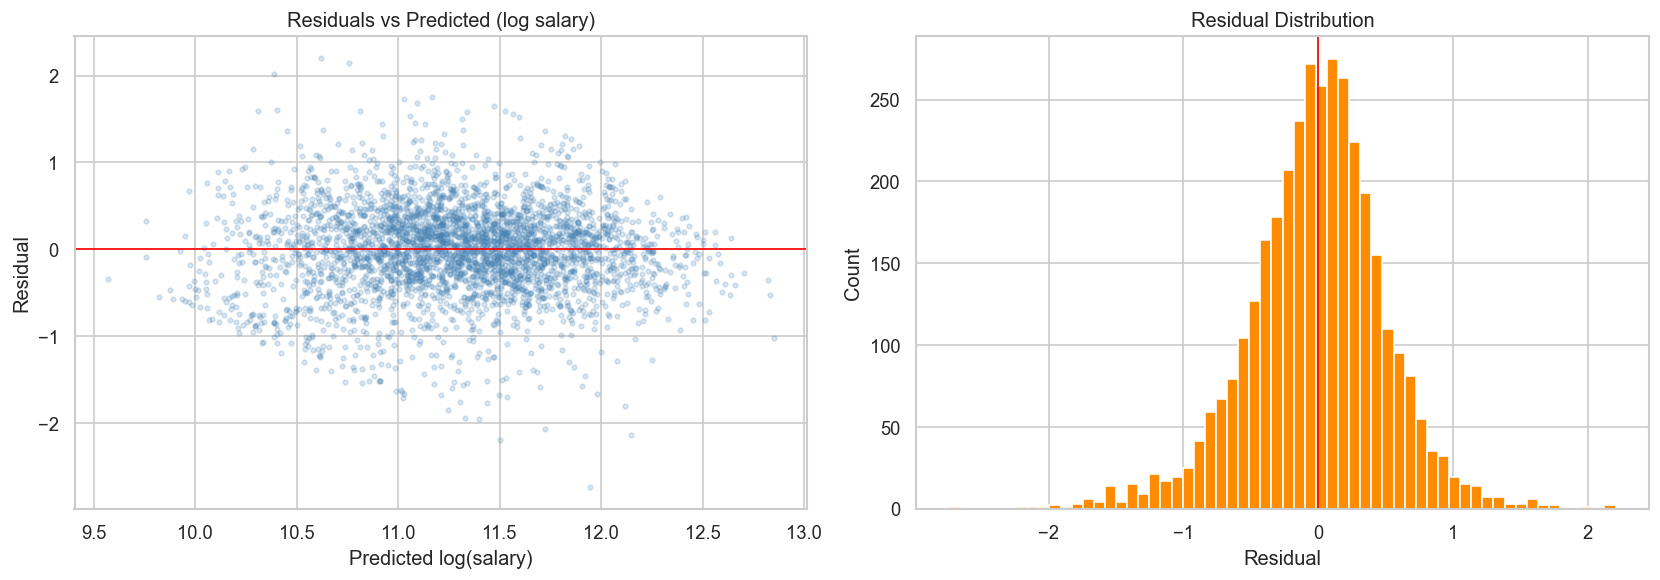

Residual mean : -0.0131
Residual std  : 0.5057


In [9]:
y_pred_test = test_res['y_pred_log']
residuals   = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_test, residuals, alpha=0.2, s=8, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_title('Residuals vs Predicted (log salary)')
axes[0].set_xlabel('Predicted log(salary)')
axes[0].set_ylabel('Residual')

# Residual distribution
axes[1].hist(residuals, bins=60, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../reports/lr_residuals.png', bbox_inches='tight')
plt.show()

print(f'Residual mean : {residuals.mean():.4f}')
print(f'Residual std  : {residuals.std():.4f}')

## Predicted vs Actual Plot

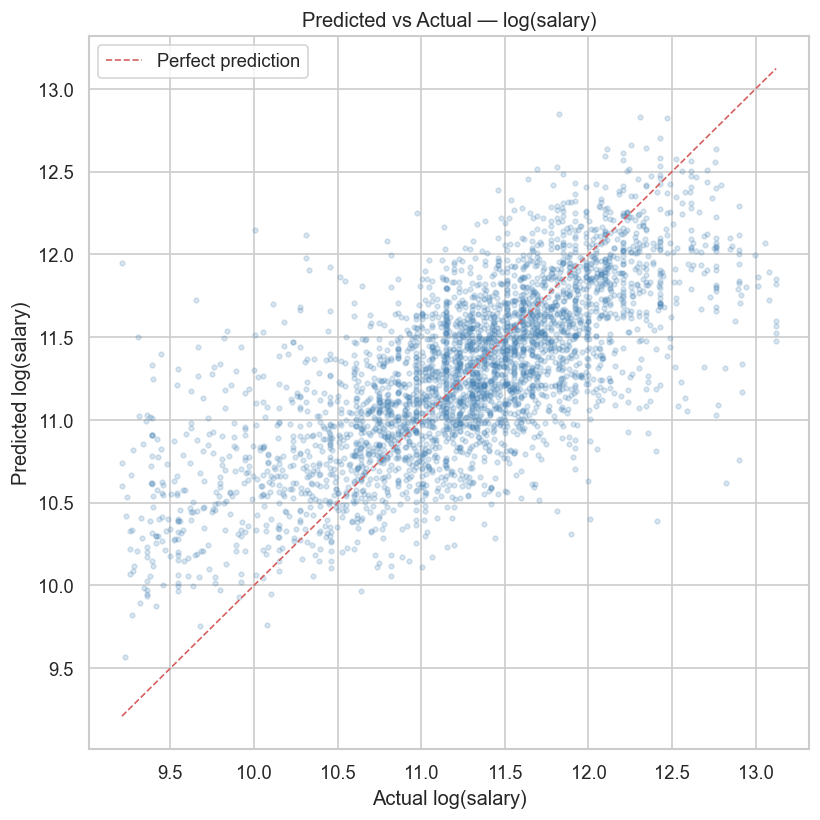

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_test, alpha=0.2, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_title('Predicted vs Actual — log(salary)')
ax.set_xlabel('Actual log(salary)')
ax.set_ylabel('Predicted log(salary)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/lr_predicted_vs_actual.png', bbox_inches='tight')
plt.show()

## Top Feature Coefficients

In [11]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef': lr.coef_
}).sort_values('coef', ascending=False)

print('Top 15 positive coefficients (salary boosters):')
print(coef_df.head(15).to_string(index=False))
print()
print('Top 15 negative coefficients (salary dampeners):')
print(coef_df.tail(15).sort_values('coef').to_string(index=False))

Top 15 positive coefficients (salary boosters):
                                   feature     coef
                      region_North_America 0.750258
                            region_Oceania 0.382492
 role_Senior executive (C-suite, VP, etc.) 0.348083
                     region_Western_Europe 0.291005
                  role_Engineering manager 0.273545
                              db_Snowflake 0.162539
                      role_Product manager 0.161436
                    role_Applied scientist 0.154065
                       role_AI/ML engineer 0.149521
     role_Architect, software or solutions 0.141549
        role_Cloud infrastructure engineer 0.115070
                         db_Databricks_SQL 0.108922
                               db_BigQuery 0.108484
                                lang_Scala 0.108007
role_Cybersecurity or InfoSec professional 0.104814

Top 15 negative coefficients (salary dampeners):
                         feature      coef
               region_South

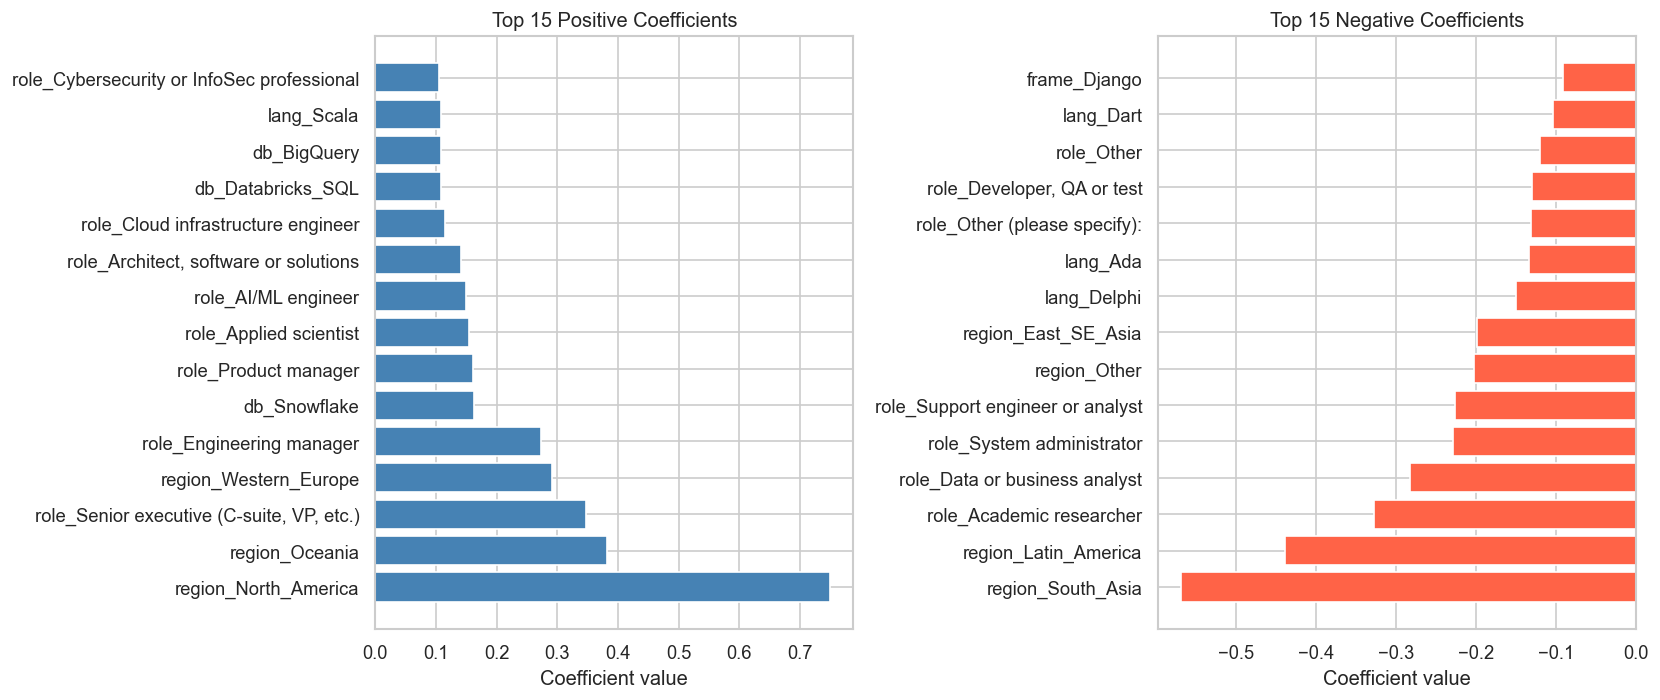

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top15    = coef_df.head(15)
bottom15 = coef_df.tail(15).sort_values('coef')

axes[0].barh(top15['feature'], top15['coef'], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Positive Coefficients')
axes[0].set_xlabel('Coefficient value')

axes[1].barh(bottom15['feature'], bottom15['coef'], color='tomato', edgecolor='white')
axes[1].set_title('Top 15 Negative Coefficients')
axes[1].set_xlabel('Coefficient value')

plt.tight_layout()
plt.savefig('../reports/lr_coefficients.png', bbox_inches='tight')
plt.show()

## Baseline Results — Comparison Table

## Phase 5 Summary

| Model | R² (test) | MAE (log) | RMSE (log) | MAE ($) | RMSE ($) |
|-------|-----------|-----------|------------|----------|-----------|
| Linear Regression | 0.5057 | 0.3813 | 0.5058 | $34,683 | $54,731 |

**Train vs Test:**
- Train R²: 0.5123 → Test R²: 0.5057 — minimal overfitting, model generalises well
- Residual mean: -0.0131 (nearly unbiased) · Residual std: 0.5057

**Top salary boosters (positive coefficients):**
-  +0.75 ·  +0.38 ·  +0.35 ·  +0.29 ·  +0.27
- Tech:  +0.16 ·  +0.11 ·  +0.11 ·  +0.11

**Top salary dampeners (negative coefficients):**
-  -0.57 ·  -0.44 ·  -0.33 ·  -0.28
- Tech:  -0.15 ·  -0.13 ·  -0.10 ·  -0.09

**Interpretation:** Location dominates — being in North America adds ~0.75 log units (~+$54k at median). Role matters second. Individual language/database choice has smaller but real effects.

**Next:** Phase 6 will train Ridge, Lasso, and XGBoost to push R² above 0.60 target.